<a href="https://colab.research.google.com/github/ImageAcharya/kb_augmented_attention_seq2seq/blob/main/KB-Augmented-Seq2Seq-Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries

import os, csv, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from transformers import AutoTokenizer, AutoModel


In [ ]:
# Setup Device & Load Models

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-Embedding-0.6B", padding_side="left")
embed_model = AutoModel.from_pretrained("Qwen/Qwen3-Embedding-0.6B")


In [ ]:
# Preprocessing

def preprocess_text(text):
    """Basic lowercase + punctuation cleaning"""
    text = text.lower()
    for char in ["?", "'", ",", ".", "1)", "2)", "3)", "4)"]:
        text = text.replace(char, " ")
    return text.strip()


In [ ]:
# Load Data

with open("qa_pairs.json", "r") as f:
    qa_data = json.load(f)

with open("key_value.json", "r") as f:
    kv_data = json.load(f)


In [ ]:
# preprocess Q/A data
inputs = [preprocess_text(i["question"]) for i in qa_data["Q&A"]]
outputs = [preprocess_text(i["answer"]) for i in qa_data["Q&A"]]


In [ ]:
inputs[:3], outputs[:3]

(['what time is anamika s appointment',
  'what department is samuel visiting',
  'where is aarnav having their appointment'],
 ['the appointment time of anamika is 15:04',
  'samuel is visiting the cardiology department',
  'aarnav is having their appointment at bharatput hospital'])

In [ ]:

# preprocess key-value data
kv_data_clean = {preprocess_text(k): preprocess_text(v) for k, v in kv_data.items()}


In [ ]:
# initialize new key value data for stored preprocessed key value data
new_key_value_data = {}
# iterating kv data through items functions to get key value
for key, value in kv_data.items():
    # preprocess key
    new_key = preprocess_text(key)
    # preprocess value
    new_value = preprocess_text(value)
    # add data into new key value data
    new_key_value_data[new_key] = new_value

In [ ]:
# Replace values with canonical keys

def replace_vals_with_keys(texts, mapping):
    for i, txt in enumerate(texts):
        for key, val in mapping.items():
            name = key.split("_")[0]
            if name in txt and val in txt:
                texts[i] = txt.replace(val, key)
                break
    return texts


In [ ]:
# call replace values with keys with output and newkeyvalue data parameters
outputs = replace_vals_with_keys(outputs, new_key_value_data)

In [ ]:

all_keys = list(kv_data_clean.keys())


In [ ]:
# add special tokens for keys
tokenizer.add_tokens(all_keys)
embed_model.resize_token_embeddings(len(tokenizer))


Embedding(152215, 1024)

In [ ]:
# Map used token IDs

used_token_ids = set()
for key in all_keys:
    ids = tokenizer.encode(key, add_special_tokens=False)
    used_token_ids.update(ids)

token_id_list = sorted(list(used_token_ids))
old2new = {old: new for new, old in enumerate(token_id_list)}
new2old = {v: k for k, v in old2new.items()}


In [ ]:
# Prepare DataFrames

qa_dict = {"INPUT": inputs, "OUTPUT": outputs}
db_df = pd.DataFrame(qa_dict)


In [ ]:
db_df

,INPUT,OUTPUT
0,what time is anamika s appointment,the appointment time of anamika is anamika_app...
1,what department is samuel visiting,samuel is visiting the samuel_checkup_departme...
2,where is aarnav having their appointment,aarnav is having their appointment at aarnav_h...
3,what time is girindra s appointment,the appointment time of girindra is girindra_a...
4,what is the contact number for aahana,the contact number for aahana is aahana_contact
...,...,...
905,what department is gayathri visiting,gayathri is visiting the gayathri_checkup_depa...
906,what time is gunbir s appointment,the appointment time of gunbir is gunbir_appoi...
907,what department is kabir visiting,kabir is visiting the kabir_checkup_department...
908,what is the contact number for chakradev,the contact number for chakradev is chakradev_...


In [ ]:

nondb_df = pd.read_csv("Prepared_Nondatabase.csv")


In [ ]:
nondb_df

,INPUT,OUTPUT
0,Hello,Hello! How are you?
1,Hi there,Hi! What’s up?
2,Hey,Hey! How’s it going?
3,What’s up?,Not much! You?
4,How’s it going?,Pretty good! You?
...,...,...
174,Want to join?,Sure!
175,What’s cooking?,Just some pasta.
176,How’s the kitchen?,Cleaned up!
177,Need groceries?,Not right now.


In [ ]:
overall_df = pd.concat([nondb_df, db_df], ignore_index=True)


In [ ]:
overall_df

,INPUT,OUTPUT
0,Hello,Hello! How are you?
1,Hi there,Hi! What’s up?
2,Hey,Hey! How’s it going?
3,What’s up?,Not much! You?
4,How’s it going?,Pretty good! You?
...,...,...
1084,what department is gayathri visiting,gayathri is visiting the gayathri_checkup_depa...
1085,what time is gunbir s appointment,the appointment time of gunbir is gunbir_appoi...
1086,what department is kabir visiting,kabir is visiting the kabir_checkup_department...
1087,what is the contact number for chakradev,the contact number for chakradev is chakradev_...


In [ ]:

overall_df["INPUT"] = overall_df["INPUT"].apply(preprocess_text)
overall_df["OUTPUT"] = overall_df["OUTPUT"].apply(preprocess_text)


In [ ]:
# Dataset Class

class QADataset(Dataset):
    def __init__(self, dataframe, max_len=8192):
        self.data = dataframe
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        question = self.data.iloc[idx]["INPUT"]
        answer = self.data.iloc[idx]["OUTPUT"]

        q_ids = tokenizer(question, truncation=True, max_length=self.max_len, return_tensors="pt")["input_ids"][0]
        a_ids = tokenizer(answer, truncation=True, max_length=self.max_len, return_tensors="pt")["input_ids"][0]
        return q_ids, a_ids


In [ ]:

dataset = QADataset(overall_df)


In [ ]:
train_set, val_set = torch.utils.data.random_split(dataset, [871, 218])
train_loader = DataLoader(train_set, batch_size=1, shuffle=True)
val_loader = DataLoader(val_set, batch_size=1, shuffle=True)


In [ ]:
# Encoder

class Encoder(nn.Module):
    def __init__(self, hidden_dim, embedding_dim=1024):
        super().__init__()
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, dropout=0.2, batch_first=True, bidirectional=True)

    def forward(self, x):
        enc_out, (h, c) = self.lstm(x)
        hidden = torch.cat([h[0], h[-1]], dim=-1)
        cell = torch.cat([c[0], c[-1]], dim=-1)
        return enc_out, hidden, cell


In [ ]:
# Decoder with KB Attention

class DecoderKBAttention(nn.Module):
    def __init__(self, embed_model, vocab_size, hidden_dim, embedding_dim=1024):
        super().__init__()
        self.embed_model = embed_model
        self.encoder = Encoder(hidden_dim, embedding_dim)
        self.decoder = nn.LSTMCell(embedding_dim, hidden_dim * 2)

        self.W_d1 = nn.Linear(hidden_dim * 4, hidden_dim)
        self.W_d2 = nn.Linear(hidden_dim, hidden_dim)
        self.w = nn.Linear(hidden_dim, 1)
        self.W_kb = nn.Linear(hidden_dim * 2, embedding_dim)

        self.proj = nn.Linear(hidden_dim * 4, vocab_size)
        self.vocab_size = vocab_size

    def decoder_attention(self, dec_hidden, enc_out):
        B, T, H = enc_out.shape
        dec_exp = dec_hidden.unsqueeze(1).expand(-1, T, -1)
        combined = torch.cat([enc_out, dec_exp], dim=2)
        x = torch.tanh(self.W_d1(combined))
        x = torch.tanh(self.W_d2(x))
        u = self.w(x).squeeze(-1)
        attn = torch.softmax(u, dim=1)
        context = torch.bmm(attn.unsqueeze(1), enc_out).squeeze(1)
        concat = torch.cat([dec_hidden, context], dim=1)
        return self.proj(concat)

    def kb_attention(self, dec_hidden, kb_keys):
        x = torch.tanh(self.W_kb(dec_hidden))
        x_norm = F.normalize(x, p=2, dim=1)
        kb_norm = F.normalize(kb_keys, p=2, dim=1)
        sim = torch.matmul(x_norm, kb_norm.T).squeeze(0)
        kb_logits = torch.zeros(x.size(0), self.vocab_size).to(device)
        for idx, val in {new2old[i]: s for i, s in enumerate(sim)}.items():
            kb_logits[:, idx] += val
        return kb_logits

    def forward(self, enc_inp, tgt_embeds, kb_keys, teacher_forcing=1.0):
        n_t = len(tgt_embeds)
        enc_out, h, c = self.encoder(enc_inp)
        logits = []
        dec_inp = tgt_embeds[0][0]

        for t in range(1, n_t):
            h, c = self.decoder(dec_inp, (h, c))
            vocab_logits = self.decoder_attention(h, enc_out)
            kb_logits = self.kb_attention(h, kb_keys).to(device)
            final_logits = vocab_logits + kb_logits
            logits.append(final_logits)

            use_tf = (torch.rand(1).item() < teacher_forcing)
            if use_tf:
                dec_inp = tgt_embeds[t][0]
            else:
                pred = torch.argmax(final_logits, dim=1)
                with torch.no_grad():
                    dec_inp = self.embed_model(pred.unsqueeze(0))["last_hidden_state"][0].detach()

        return torch.stack(logits, dim=1)


In [ ]:
# Initialize Model
vocab_size = len(tokenizer.vocab)
model = DecoderKBAttention(embed_model=embed_model, vocab_size=vocab_size, hidden_dim=320, embedding_dim=1024).to(device)


/home/Image/Documents/Image/imgenv/lib/python3.10/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


In [ ]:
vocab_size

152215

In [ ]:
# build key embeddings
keys_emb = []
for key in all_keys:
    ids = tokenizer(key, return_tensors="pt")["input_ids"][:, :-1]
    emb = embed_model(ids.to(device))["last_hidden_state"][0]
    keys_emb.append(emb)
keys_emb = torch.stack(keys_emb, dim=0).squeeze(1).detach()


In [ ]:
# Training Setup

lr = 0.001
epochs = 20
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
start_token = tokenizer("<|im_start|>", return_tensors="pt")["input_ids"][:, 0].unsqueeze(0).to(device)

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss = float("inf")



In [ ]:

# Training Loop

for epoch in range(epochs):
    model.train()
    total_loss, total_correct, total_tokens = 0, 0, 0

    for q_ids, a_ids in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        q_ids, a_ids = q_ids.to(device), a_ids.to(device)
        q_ids = q_ids[:, :-1]
        start_exp = start_token.expand(a_ids.size(0), 1).to(device)
        tgt_with_sos = torch.cat([start_exp, a_ids], dim=1)

        optimizer.zero_grad()
        with torch.no_grad():
            q_emb = embed_model(q_ids)["last_hidden_state"].detach()
            tgt_emb = [embed_model(i.unsqueeze(0).unsqueeze(0))["last_hidden_state"].detach() for i in tgt_with_sos[0]]

        teacher_forcing = 0.5 if epoch > 5 else 0.9
        logits = model(q_emb, tgt_emb, kb_keys=keys_emb, teacher_forcing=teacher_forcing)

        loss = criterion(logits.view(-1, logits.size(-1)), a_ids.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=-1)
        total_correct += (preds == a_ids).float().sum().item()
        total_tokens += a_ids.numel()

    avg_train_loss = total_loss / len(train_loader)
    train_acc = total_correct / total_tokens
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)


    # Validation

    model.eval()
    val_loss, val_correct, val_tokens = 0, 0, 0
    with torch.no_grad():
        for q_ids, a_ids in tqdm(val_loader, desc="Validation"):
            q_ids, a_ids = q_ids.to(device), a_ids.to(device)
            q_ids = q_ids[:, :-1]
            start_exp = start_token.expand(a_ids.size(0), 1).to(device)
            tgt_with_sos = torch.cat([start_exp, a_ids], dim=1)

            q_emb = embed_model(q_ids)["last_hidden_state"].detach()
            tgt_emb = [embed_model(i.unsqueeze(0).unsqueeze(0))["last_hidden_state"].detach() for i in tgt_with_sos[0]]

            teacher_forcing = 0.5 if epoch > 5 else 0.9
            val_logits = model(q_emb, tgt_emb, kb_keys=keys_emb, teacher_forcing=teacher_forcing)

            loss = criterion(val_logits.view(-1, val_logits.size(-1)), a_ids.view(-1))
            val_loss += loss.item()
            preds = torch.argmax(val_logits, dim=-1)
            val_correct += (preds == a_ids).float().sum().item()
            val_tokens += a_ids.numel()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_tokens
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "models/best_model_weight_kb.pth")

    torch.save(model.state_dict(), f"models/model_weight_kb_epoch_{epoch+1}.pth")

    print(f"Epoch {epoch+1}: "
          f"Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.4f} | "
          f"Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.4f}")


Validation: 100%|██████████| 218/218 [00:31<00:00,  6.99it/s]


Epoch 1: Train Loss=4.1121, Train Acc=0.5111 | Val Loss=2.6995, Val Acc=0.5909


Validation: 100%|██████████| 218/218 [00:31<00:00,  6.96it/s]


Epoch 2: Train Loss=1.8812, Train Acc=0.6896 | Val Loss=1.8294, Val Acc=0.7348


Validation: 100%|██████████| 218/218 [00:32<00:00,  6.72it/s]


...

Epoch 18: Train Loss=0.3183, Train Acc=0.9299 | Val Loss=1.5481, Val Acc=0.8547


Validation: 100%|██████████| 218/218 [00:36<00:00,  5.94it/s]


Epoch 19: Train Loss=0.4486, Train Acc=0.8905 | Val Loss=1.7479, Val Acc=0.8376


Validation: 100%|██████████| 218/218 [00:37<00:00,  5.78it/s]


Epoch 20: Train Loss=0.4369, Train Acc=0.8920 | Val Loss=1.7273, Val Acc=0.8245


In [ ]:
# Plot Training Curves
epochs_range = range(1, epochs+1)
plt.figure(figsize=(12,5))


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

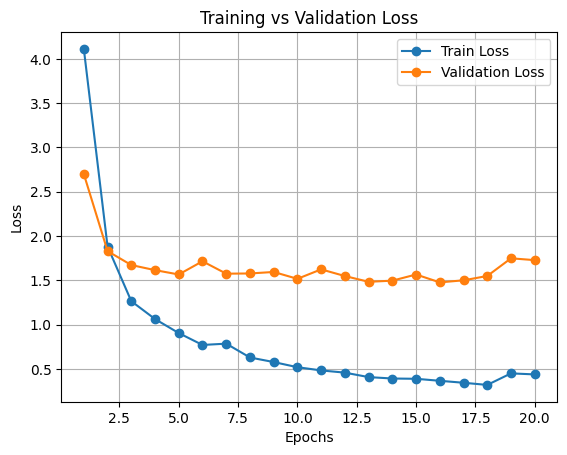

In [ ]:

# ---- Loss ----
plt.plot(epochs_range, train_losses, label="Train Loss", marker='o')
plt.plot(epochs_range, val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)


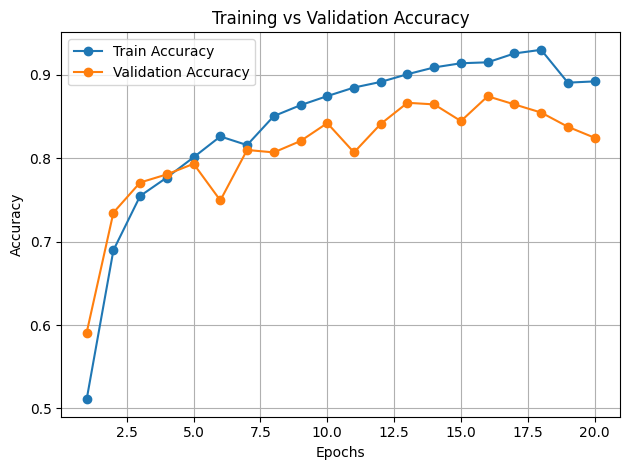

In [ ]:

# ---- Accuracy ----
plt.plot(epochs_range, train_accs, label="Train Accuracy", marker='o')
plt.plot(epochs_range, val_accs, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# load prev check point
state_dict = torch.load("models/model_weight_kb_epoch_19.pth")
load_result = model.load_state_dict(state_dict)

In [ ]:

# Inference Function

def inference(model, tokenizer, embed_model, keys_embed, device, queries, max_len=20):

    model.eval()
    embed_model = embed_model.to(device)

    for query in queries:
        print("Your Query:", query)

        # Encode input query
        input_ids = tokenizer(query, max_length=8192, truncation=True, return_tensors="pt")['input_ids'][:, :-1].to(device)
        input_embeds = embed_model(input_ids)['last_hidden_state']
        enc_out, hidden, cell = model.encoder(input_embeds)


        # Start token embedding
        start_token_id = tokenizer('<|im_start|>', return_tensors="pt")['input_ids'][:, 0].unsqueeze(0).to(device)
        input_emb = embed_model(start_token_id)['last_hidden_state'][:, 0, :]

        generated_tokens = []

        for _ in range(max_len):
            hidden, cell = model.decoder(input_emb, (hidden, cell))

            vocab_logits = model.decoder_attention(hidden, enc_out)
            kb_logits = model.kb_attention(hidden, keys_embed).to(device)
            final_logits = vocab_logits + kb_logits

            next_token_id = torch.argmax(final_logits, dim=1).item()

            # Stop if stop token is generated
            if next_token_id == 151643:
                break

            generated_tokens.append(next_token_id)
            input_emb = embed_model(torch.tensor([[next_token_id]]).to(device))['last_hidden_state'][:, 0, :]

        # Decode tokens to text
        response_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

        # Map keys back to original values if needed
        final_text = ""
        for idx, token in enumerate(response_text.split()):
            if token in all_keys:
                final_text += new_key_value_data[token]
            else:
                if idx != 0:
                    if response_text.split()[idx - 1] != token:
                        final_text += token
                else:
                    final_text += token
            final_text += " "

        print("Model Response:", final_text.strip())
        print("-" * 50)



In [ ]:
# Example Usage

queries_list = [
    "What is the contact number for Gaurav?",
    "Any plans today?"
]

inference(model=model, tokenizer=tokenizer, embed_model=embed_model, keys_embed=keys_emb, device=device, queries=queries_list)


Your Query: What is the contact number for Gaurav?
Model Response: the contact number  for gavav is +917427389653
--------------------------------------------------
Your Query: Any plans today?
Model Response: not yet yet!
--------------------------------------------------
